In [1]:
!uv add numpy
!uv add pandas
!uv add matplotlib
!uv add seaborn
!uv add wordcloud

Resolved 58 packages in 5ms
Checked 55 packages in 8ms
Resolved 58 packages in 4ms
Checked 55 packages in 3ms
Resolved 58 packages in 4ms
Checked 55 packages in 3ms
Resolved 58 packages in 4ms
Checked 55 packages in 3ms
Resolved 58 packages in 4ms
Checked 55 packages in 3ms


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from wordcloud import WordCloud

In [3]:
import warnings
warnings.filterwarnings("ignore")

In [4]:
DATA_PATH = "./data"
OUTPUT_PATH = "./output"

In [5]:
import os
os.makedirs("./output", exist_ok=True)

In [6]:
# plot settings
sns.set_style("whitegrid")

plt.rcParams.update({
  "figure.dpi": 150,
  "figure.figsize": (12, 6),
  "axes.spines.right": False,
  "axes.spines.top": False,
  "axes.labelsize": 14,
  "axes.titlesize": 16,
})

In [7]:
# loading full datasets
df_full = pd.read_csv(f"{DATA_PATH}/sentiment.csv", encoding="latin-1", low_memory=False)
df_full.head(1)

,ProductName,ProductPrice,Rate,Review,Summary,Sentiment
0,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,Super!,great cooler excellent air flow and for this p...,positive


In [8]:
# summary of df_full dataframe
summary = pd.DataFrame({
  "data_type": df_full.dtypes,
  "missing_values": df_full.isnull().sum(),
  "n_unique_values": df_full.nunique(),
  "sample": df_full.iloc[0],
})
print(f"{df_full.shape[0]} rows and {df_full.shape[1]} columns in the full dataset.\n")
print(summary)

171380 rows and 6 columns in the full dataset.

             data_type  missing_values  n_unique_values  \
ProductName        str               0              963   
ProductPrice       str               1              622   
Rate               str               1                6   
Review             str               1             1336   
Summary            str               1            85074   
Sentiment          str               1                6   

                                                         sample  
ProductName   Candes 12 L Room/Personal Air Cooler??????(Whi...  
ProductPrice                                               3999  
Rate                                                          5  
Review                                                   Super!  
Summary       great cooler excellent air flow and for this p...  
Sentiment                                              positive  


In [9]:
# loading equal datasets
df_equal = pd.read_csv(f"{DATA_PATH}/equal.csv", encoding="latin-1", low_memory=False)
df_equal.head(1)

,product_name,product_price,Rate,Review,Summary,Sentiment
0,SportSoul Cotton Gym & Athletic Abdomen Suppor...,449,4,good quality product,good cuality,positive


In [10]:
summary = pd.DataFrame({
  "data_type": df_equal.dtypes,
  "missing_values": df_equal.isnull().sum(),
  "n_unique_values": df_equal.nunique(),
  "sample": df_equal.iloc[0],
})
print(f"{df_equal.shape[0]} rows and {df_equal.shape[1]} columns in the equal dataset.\n")
print(summary)

76704 rows and 6 columns in the equal dataset.

              data_type  missing_values  n_unique_values  \
product_name        str               0             1679   
product_price       str               0              889   
Rate                str               0                6   
Review              str               0              637   
Summary             str               0            41928   
Sentiment           str               0                3   

                                                          sample  
product_name   SportSoul Cotton Gym & Athletic Abdomen Suppor...  
product_price                                                449  
Rate                                                           4  
Review                                      good quality product  
Summary                                             good cuality  
Sentiment                                               positive  


In [11]:
# loading ratio datasets
df_ratio = pd.read_csv(f"{DATA_PATH}/ratio.csv", encoding="latin-1", low_memory=False)
df_ratio.head(1)

,product_name,product_price,Rate,Review,Summary,Sentiment
0,SAMSUNG 198 L Direct Cool Single Door 5 Star R...,???????????????????????????????????...,1,Very poor,problems 1 it gets auto defrost randomly anyti...,positive


In [12]:
summary = pd.DataFrame({
  "data_type": df_ratio.dtypes,
  "missing_values": df_ratio.isnull().sum(),
  "n_unique_values": df_ratio.nunique(),
  "sample": df_ratio.iloc[0],
})
print(f"{df_ratio.shape[0]} rows and {df_ratio.shape[1]} columns in the ratio dataset.\n")
print(summary)

64218 rows and 6 columns in the ratio dataset.

              data_type  missing_values  n_unique_values  \
product_name        str               0             1007   
product_price       str               0              665   
Rate              int64               0                5   
Review              str               0              568   
Summary             str               0            33678   
Sentiment           str               0                3   

                                                          sample  
product_name   SAMSUNG 198 L Direct Cool Single Door 5 Star R...  
product_price  ???????????????????????????????????...  
Rate                                                           1  
Review                                                 Very poor  
Summary        problems 1 it gets auto defrost randomly anyti...  
Sentiment                                               positive  


In [13]:
# get target unique values
print(f"unique values in full dataset: {df_full['Sentiment'].unique()}\n")
print(f"unique values in equal dataset: {df_equal['Sentiment'].unique()}\n")
print(f"unique values in ratio dataset: {df_ratio['Sentiment'].unique()}")

unique values in full dataset: <StringArray>
['positive', 'negative', 'neutral', 'Negative', 'Neutral', 'Positive', nan]
Length: 7, dtype: str

unique values in equal dataset: <StringArray>
['positive', 'neutral', 'negative']
Length: 3, dtype: str

unique values in ratio dataset: <StringArray>
['positive', 'neutral', 'negative']
Length: 3, dtype: str


In [14]:
# lowercase the target values for consistency
df_full["Sentiment"] = df_full["Sentiment"].str.lower().str.strip()
df_equal["Sentiment"] = df_equal["Sentiment"].str.lower().str.strip()
df_ratio["Sentiment"] = df_ratio["Sentiment"].str.lower().str.strip()

In [15]:
# preprocess the missing value for Sentiment column in full dataset
df_full.dropna(subset=["ProductPrice", "Rate", "Review", "Summary", "Sentiment"], inplace=True)

In [16]:
# datasets
datasets = {
    "Full Dataset\n(sentiment.csv)": df_full,
    "Balanced Dataset\n(Equal.csv)": df_equal,
    "Ratio Dataset\n(RATIO.csv)": df_ratio
}

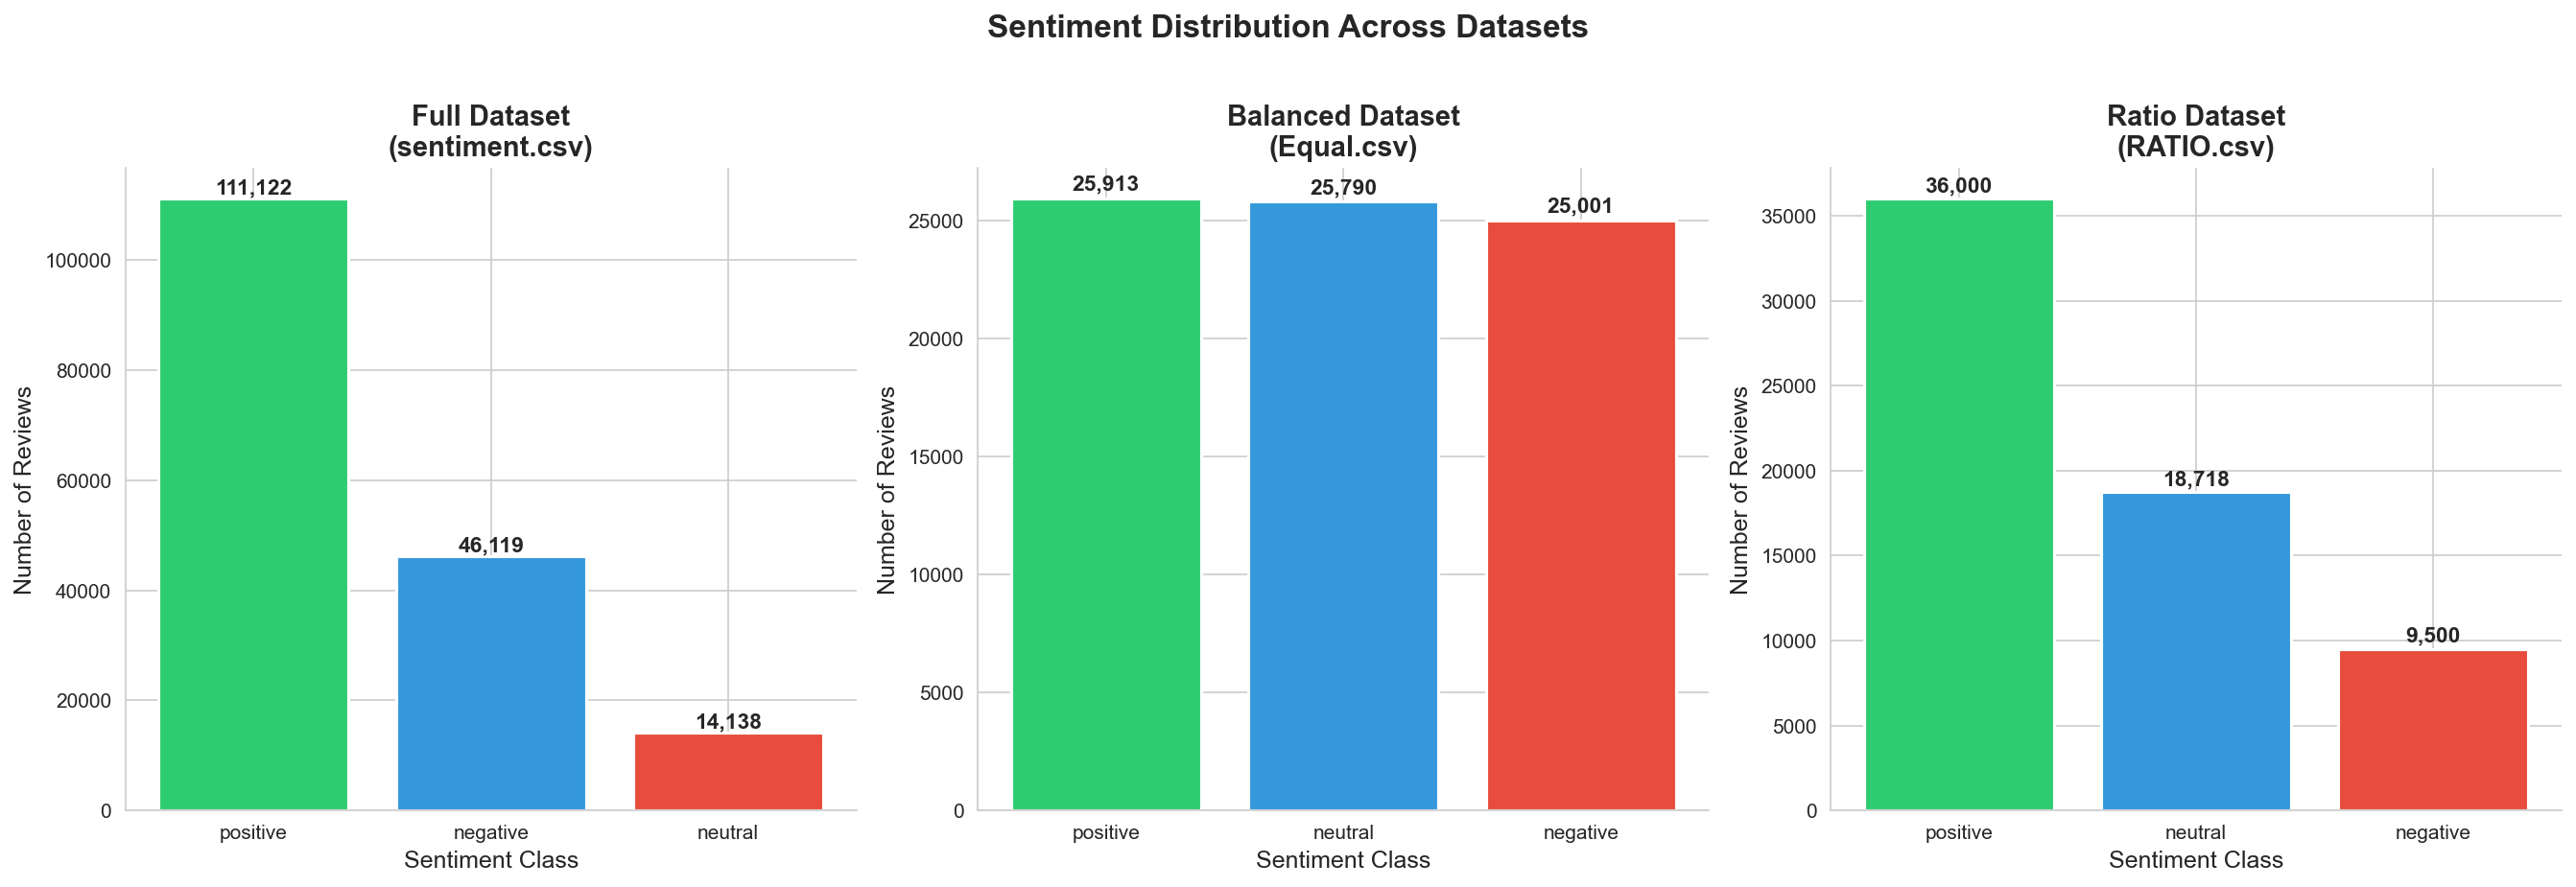

<Figure size 1800x900 with 0 Axes>

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors = ['#2ecc71', '#3498db', '#e74c3c']

for ax, (title, df) in zip(axes, datasets.items()):
    counts = df['Sentiment'].value_counts()
    bars = ax.bar(counts.index, counts.values, color=colors[:len(counts)], edgecolor='white', linewidth=1.5)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Sentiment Class', fontsize=12)
    ax.set_ylabel('Number of Reviews', fontsize=12)
    for bar, count in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 200,
                f'{count:,}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=0)


plt.suptitle('Sentiment Distribution Across Datasets', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
plt.savefig(f'{OUTPUT_PATH}/sentiment_distribution.png', bbox_inches='tight')
plt.close()


plt.suptitle('Sentiment Distribution Across Datasets', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}/sentiment_distribution.png', bbox_inches='tight')
plt.show()
plt.close()

In [18]:
# add extra word and char count
for dataset in datasets.values():
  dataset["review_word_count"] = dataset["Review"].str.split().str.len()
  dataset["review_char_count"] = dataset["Review"].str.len()

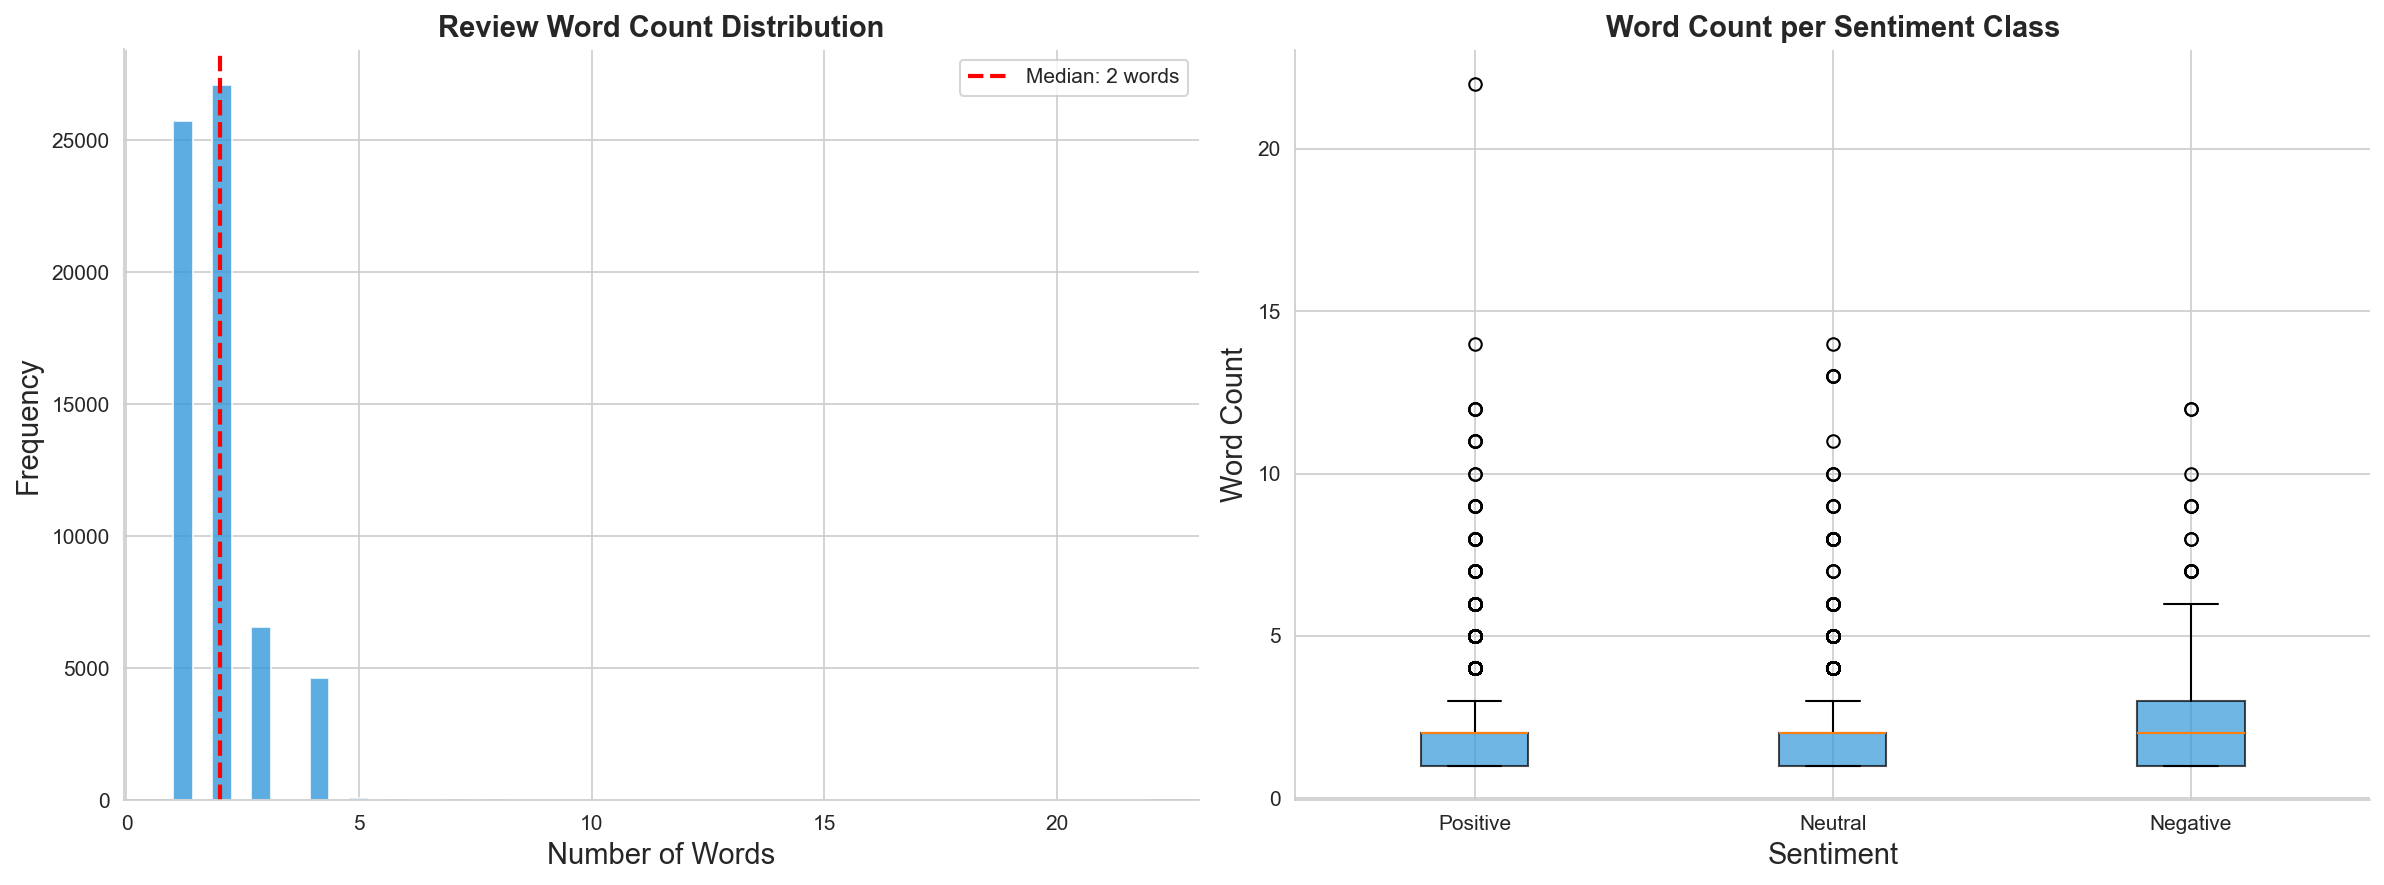

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].hist(df['review_word_count'].clip(upper=200),
             bins=50, color='#3498db', edgecolor='white', alpha=0.8)
axes[0].axvline(df['review_word_count'].median(), color='red', linestyle='--', linewidth=2,
                label=f"Median: {df['review_word_count'].median():.0f} words")
axes[0].set_title('Review Word Count Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Words')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].boxplot(
    [df[df['Sentiment'] == s]['review_word_count'].clip(upper=100) for s in ['positive', 'neutral', 'negative']],
    labels=['Positive', 'Neutral', 'Negative'],
    patch_artist=True,
    boxprops=dict(facecolor='#3498db', alpha=0.7)
)
axes[1].set_title('Word Count per Sentiment Class', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Word Count')

plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}/review_length_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

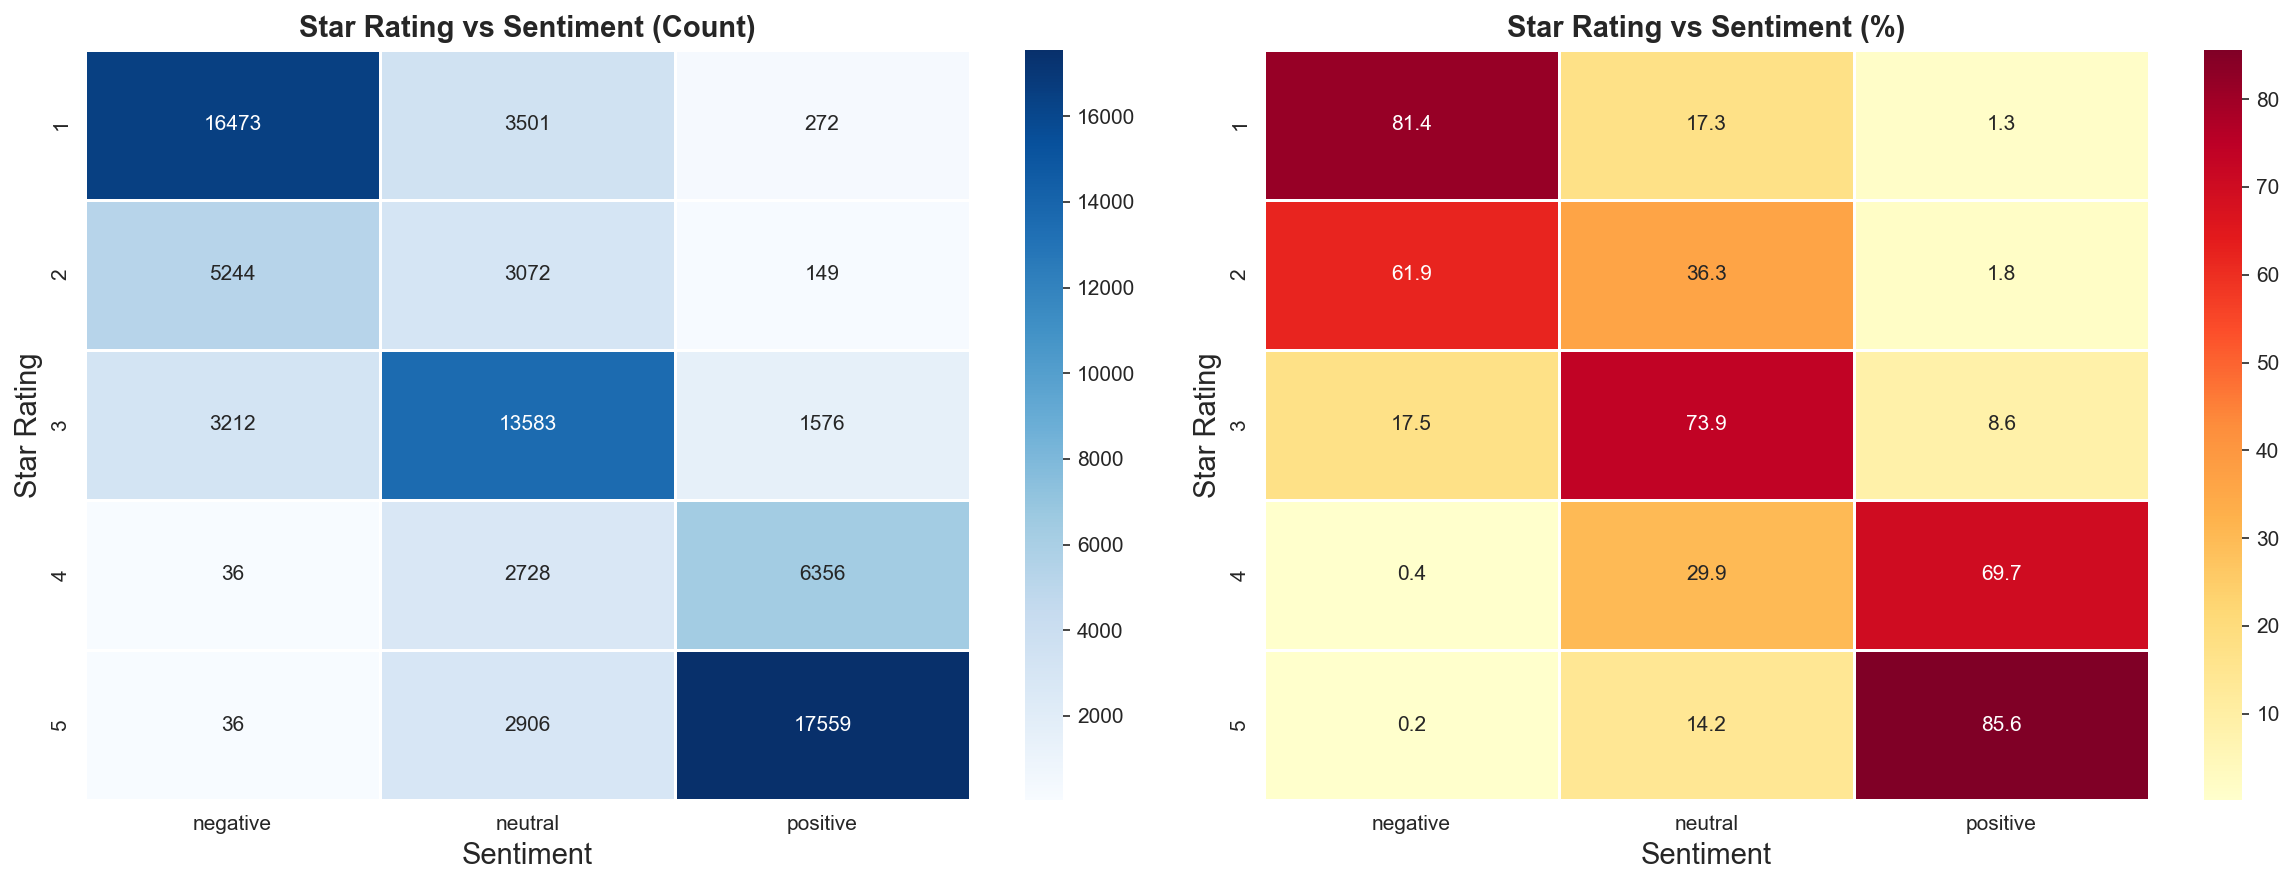

In [20]:
df_equal_clean = df_equal.copy()
df_equal_clean['Rate'] = pd.to_numeric(df_equal_clean['Rate'], errors='coerce')
df_equal_clean = df_equal_clean.dropna(subset=['Rate'])
df_equal_clean['Rate'] = df_equal_clean['Rate'].round().astype(int)
df_equal_clean = df_equal_clean[df_equal_clean['Rate'].between(1, 5)]

ct = pd.crosstab(df_equal_clean['Rate'], df_equal_clean['Sentiment'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(ct, annot=True, fmt='d', cmap='Blues', ax=axes[0], linewidths=0.5)
axes[0].set_title('Star Rating vs Sentiment (Count)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Star Rating')

ct_norm = ct.div(ct.sum(axis=1), axis=0) * 100
sns.heatmap(ct_norm, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[1], linewidths=0.5)
axes[1].set_title('Star Rating vs Sentiment (%)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Star Rating')

plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}/rating_vs_sentiment.png', bbox_inches='tight')
plt.show()
plt.close()

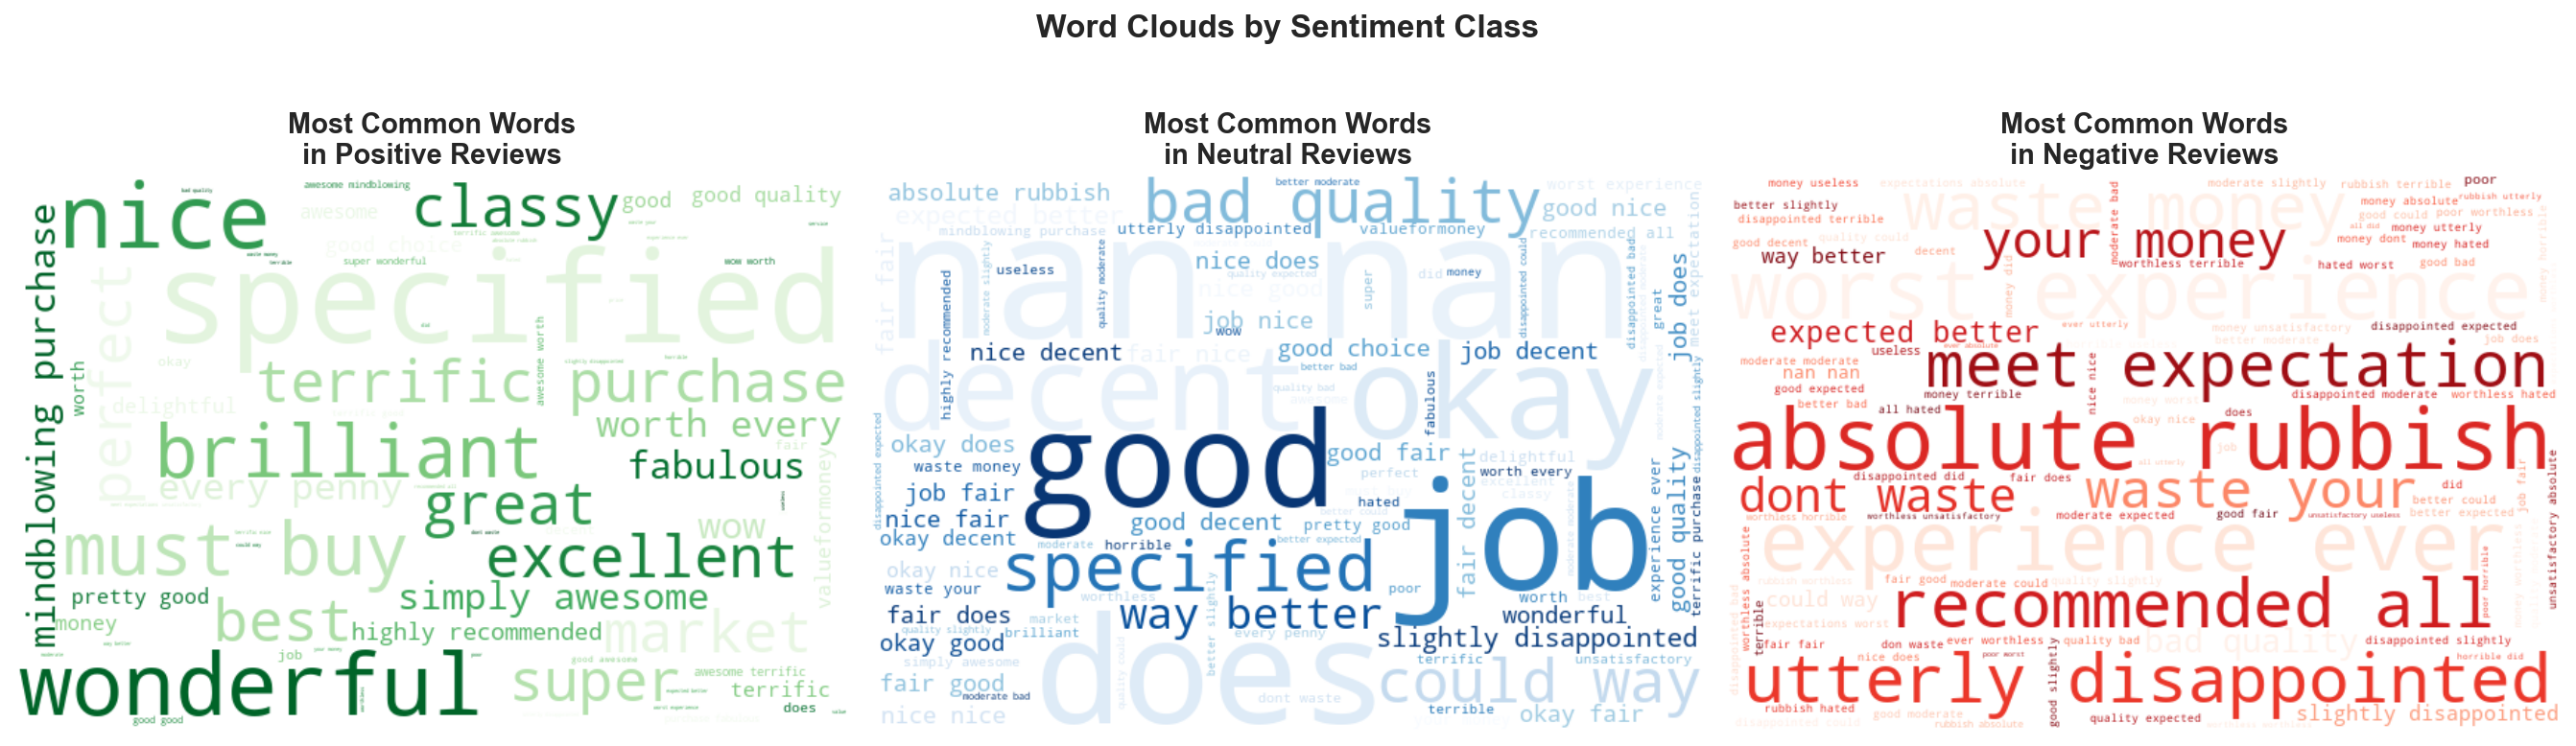

In [21]:
import re

def simple_clean(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    return text

STOPWORDS = {
    'the', 'a', 'an', 'is', 'it', 'this', 'that', 'and', 'or', 'but',
    'in', 'on', 'at', 'to', 'for', 'of', 'with', 'i', 'my', 'have',
    'was', 'are', 'be', 'its', 'product', 'item', 'got', 'very', 'so',
    'just', 'also', 'not', 'would', 'really', 'get', 'use', 'used',
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sentiments = ['positive', 'neutral', 'negative']
cloud_colors = ['Greens', 'Blues', 'Reds']

for ax, sentiment, colormap in zip(axes, sentiments, cloud_colors):
    texts = df_equal[df_equal['Sentiment'] == sentiment]['Review'].dropna()
    combined = ' '.join(texts.apply(simple_clean))
    wc = WordCloud(
        width=600, height=400,
        background_color='white',
        colormap=colormap,
        stopwords=STOPWORDS,
        max_words=100,
        min_word_length=3,
    ).generate(combined)

    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'Most Common Words\nin {sentiment.capitalize()} Reviews',
                 fontsize=14, fontweight='bold')

plt.suptitle('Word Clouds by Sentiment Class', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}/word_clouds.png', bbox_inches='tight')
plt.show()
plt.close()

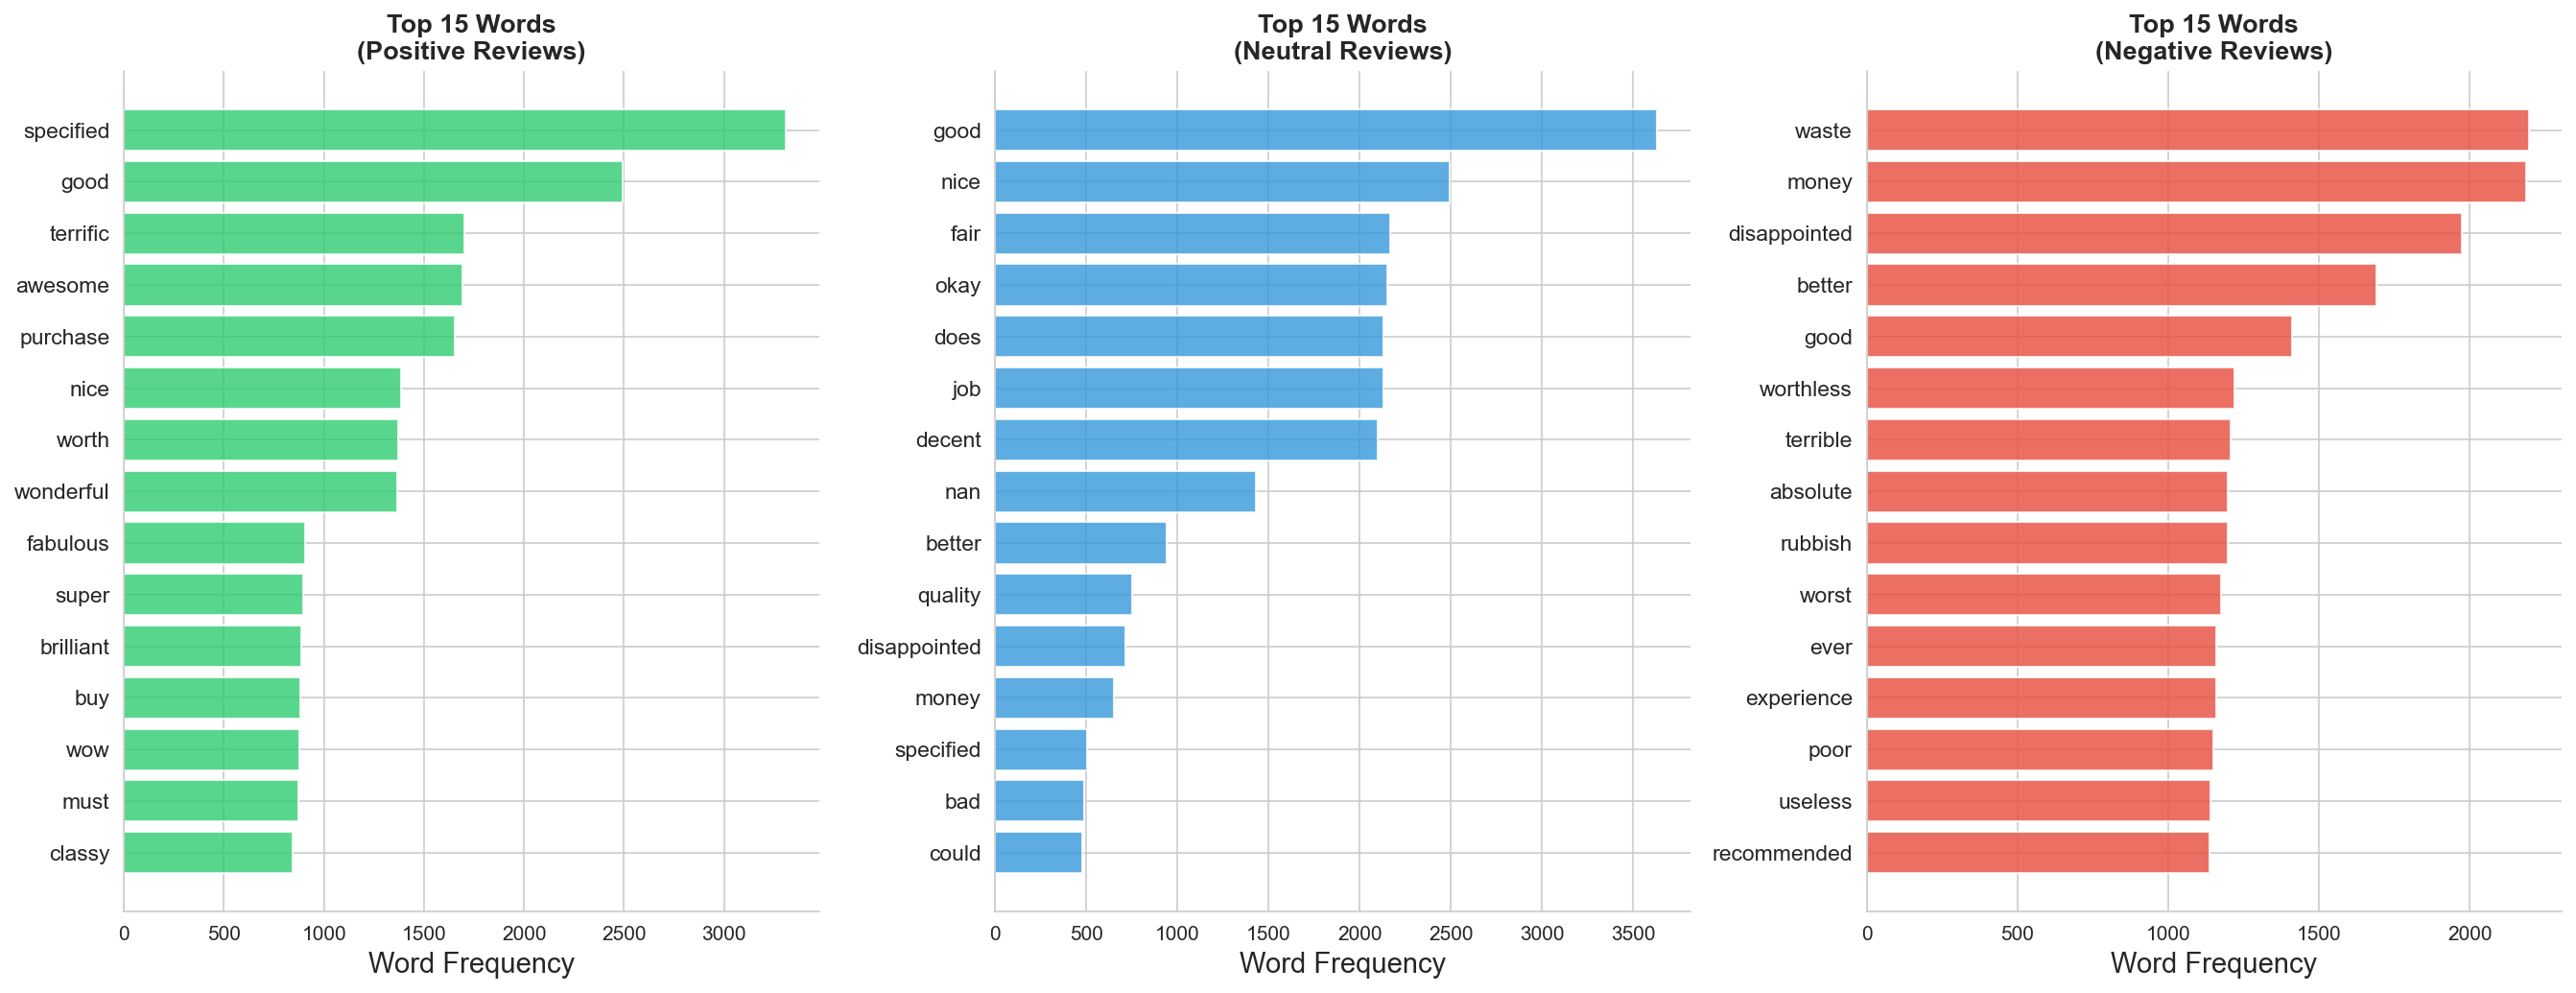

In [22]:
from collections import Counter

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for ax, sentiment in zip(axes, ['positive', 'neutral', 'negative']):
    texts = df_equal[df_equal['Sentiment'] == sentiment]['Review'].dropna()
    all_words = []

    for review in texts:
        clean = simple_clean(str(review))
        words = [w for w in clean.split() if w not in STOPWORDS and len(w) >= 3]
        all_words.extend(words)

    top_words = Counter(all_words).most_common(15)
    words, counts = zip(*top_words)

    color = {'positive': '#2ecc71', 'neutral': '#3498db', 'negative': '#e74c3c'}[sentiment]
    ax.barh(range(len(words)), counts, color=color, alpha=0.8, edgecolor='white')
    ax.set_yticks(range(len(words)))
    ax.set_yticklabels(words, fontsize=11)
    ax.invert_yaxis()
    ax.set_title(f'Top 15 Words\n({sentiment.capitalize()} Reviews)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Word Frequency')

plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}/top_words_per_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()